# Midterm Project: Restaurants 🍔🍟

## Due Friday, February 13th at 11:59PM

Welcome to the Midterm Project! Projects in DSC 10 are similar in format to homeworks, but are different in a few key ways. First, a project is comprehensive, meaning that it draws upon everything we've learned this quarter so far. Second, since problems can vary quite a bit in difficulty, some problems will be worth more points than others. Finally, in a project, the problems are more open-ended; they will usually ask for some result, but won't tell you what method should be used to get it. There might be several equally-valid approaches, and several steps might be necessary. This is closer to how data science is done in "real life."

It is important that you **start early** on the project! It will take the place of a homework in the week that it is due, but you should also expect it to take longer than a homework. You are especially encouraged to **find a partner** to work through the project with. If you work in a pair, you must follow the [Project Partner Guidelines](https://dsc10.com/project-partners/) on the course website. In particular, you must work together at the same time, and you are not allowed to split up the project and each work on certain problems. If you work with a partner, only one of you needs to upload your notebook to Gradescope; after uploading, you'll see an option to add the other partner to the submission.

**Important:** The `otter` tests don't usually tell you that your answer is correct. More often, they help catch basic mistakes. It's up to you to ensure that your answer is correct. If you're not sure, ask someone (not for the answer, but for some guidance about your approach). Directly sharing answers between groups is not okay, but discussing problems with the course staff or with other students is encouraged.

**Please do not use for-loops or import any packages.** Loops in Python are slow, and looping over arrays and DataFrames should usually be avoided in favor of commands that are meant specifically for these objects. This entire project can be done without any loops, using the tools we've learned so far in DSC 10. Please do no import any additional packages - you don't need them, and our autograder may not be able to run your code if you do.

As you work through this project, there are a few resources you may want to have open:
- [DSC 10 Reference Sheet](https://dsc-courses.github.io/bpd-reference/docs/documentation/intro/)
- [`babypandas` notes](https://notes.dsc10.com/front.html)
- Other links in the [Resources](https://dsc10.com/resources/) and [Debugging](https://dsc10.com/debugging/) tabs of the course website

Start early, good luck, and let's begin! 🏃

In [1]:
# Please don't change this cell but do run it.
import babypandas as bpd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.style.use('seaborn-v0_8-colorblind')

import otter
grader = otter.Notebook()

np.set_printoptions(legacy='1.21')

## Outline

Use this outline to help you quickly navigate to the part of the project you're working on:
- [The Data](#data)    
- [Part 1. Chains ⛓️](#part1) 
    - Questions 1.1 - 1.12    
- [Part 2. Cities 🌆](#part2) 
    - Questions 2.1 - 2.8
- [Part 3. Stars ⭐️](#part3) 
    - Questions 3.1 - 3.6

<a id='data'></a>
## The Data

In this project, we will explore several restaurant rankings from [Restaurant Business](https://www.restaurantbusinessonline.com) (RB), a media brand that provides business intelligence insights for commercial restaurants. The data is a few years old; it was collected in 2022 and includes information on year-end sales from 2021. 

Our data is split across three different CSV files, each of which contains a different set of restaurants, using a different ranking methodology. Run the cell below to load in our data as DataFrames.

In [2]:
future = bpd.read_csv('data/Future50.csv')

independents = bpd.read_csv('data/Independents100.csv')

chain_restaurants = bpd.read_csv('data/Top250.csv')

The `future` DataFrame contains information about the 50 fastest-growing restaurant chains in the US whose yearly sales are between 25 and 50 million dollars.  Because of the moderate range for yearly sales, the `future` DataFrame does not include restaurant giants like McDonald's and Starbucks. Instead, the restaurant chains in the `future` DataFrame are mid-sized restaurant chains that may boom in popularity in the future, hence the DataFrame's name.

The `future` DataFrame is sorted in descending order of 2021 `'Sales'`, which are reported in millions in dollars. The DataFrame also includes the percentage change in sales from 2020 to 2021 ('YOY_Sales'; YOY stands for "Year-over-Year"). The `'Location'` column refers to the city where the chain is headquartered, not to any specific location. 

Run the cell below to take a look at the `future` DataFrame, and [click here](https://www.restaurantbusinessonline.com/future-50-2022) to see the ranking on RB's website.

In [3]:
future

,Rank,Restaurant,Location,Sales,YOY_Sales,Units,YOY_Units,Unit_Volume,Franchising
0,1,Duck Donuts,"Mechanicsburg, Pa.",50,28.50%,106,10.40%,495,Yes
1,2,Just Salad,"New York, N.Y.",50,28.10%,48,14.30%,1105,No
2,3,Eggs Up Grill,"Spartanburg, S.C.",49,71.20%,53,15.20%,992,Yes
3,4,Bubbakoo's Burritos,"Wall, N.J.",48,58.50%,63,46.50%,900,Yes
4,5,Pokeworks,"Irvine, Calif.",47,32.50%,65,14.00%,775,Yes
...,...,...,...,...,...,...,...,...,...
45,46,Starbird Chicken,"Sunnyvale, Calif.",21,78.30%,10,25.00%,3600,Yes
46,47,GFG Cafe Cuisine,"Rutherford, N.J.",20,111.60%,30,66.70%,840,Yes
47,48,Mango Mango Desserts,"New York, N.Y.",19,35.00%,26,23.80%,820,Yes
48,49,Common Bond Cafe,"Houston, Texas",19,35.30%,10,11.10%,1980,No


The `independents` DataFrame contains information about the 100 highest-grossing independent restaurants in the US in 2021, sorted by `'Sales'` in decreasing order. Here, `'Sales'` are measured in dollars, not in millions of dollars. A restaurant is classified as "independent" if it has fewer than five locations; unlike in the `future` DataFrame, the `'City'` column here corresponds to the actual location of the restaurant.

In [4]:
independents

,Rank,Restaurant,Sales,Average Check,City,State,Meals Served
0,1,Komodo,41000000,115,Miami,Fla.,285000
1,2,The Boathouse Orlando,39863628,44,Orlando,Fla.,921785
2,3,Swan,31000000,85,Miami,Fla.,185000
3,4,Maple & Ash (Chicago),30285684,106,Chicago,Ill.,285714
4,5,Mila,27350000,134,Miami Beach,Fla.,203990
...,...,...,...,...,...,...,...
95,96,George's at the Cove,11218000,93,La Jolla,Calif.,221671
96,97,Stubborn Seed,11158000,124,Miami Beach,Fla.,89986
97,98,Toulouse Cafe & Bar Houston,11074759,78,Houston,Texas,113609
98,99,L'Atelier de Joël Robuchon Miami,11063000,195,Miami,Fla.,54215


Finally, the `chain_restaurants` DataFrame contains information about the 250 largest restaurant chains in the US in 2020, sorted by `'Sales'` in decreasing order. Here, sales are measured in millions, so McDonald's sales value of `40517` really means \$40.5 billion dollars.

Run the cell below to take a look at the `chain_restaurants` DataFrame.

In [5]:
chain_restaurants

,Rank,Restaurant,Sales,YOY_Sales,Units,YOY_Units,Segment,Category,Segment_Category
0,1,McDonald's,40517,0.30%,13682,-1.20%,Quick Service,Burger,Quick Service & Burger
1,2,Starbucks,18485,-13.50%,15337,1.90%,Quick Service,Coffee Cafe,Quick Service & Coffee Cafe
2,3,Chick-fil-A,13745,13.00%,2659,6.70%,Quick Service,Chicken,Quick Service & Chicken
3,4,Taco Bell,11294,0.00%,6799,0.50%,Quick Service,Mexican,Quick Service & Mexican
4,5,Wendy's,10231,4.80%,5881,0.50%,Quick Service,Burger,Quick Service & Burger
...,...,...,...,...,...,...,...,...,...
245,246,American Deli,98,2.00%,182,2.80%,Quick Service,Sandwich,Quick Service & Sandwich
246,247,Bonchon,98,-19.50%,109,6.90%,Casual Dining,Asian,Casual Dining & Asian
247,248,Chopt,98,-12.40%,65,0.00%,Fast Casual,All Other,Fast Casual & All Other
248,249,Chicken Express,96,-6.50%,260,2.80%,Quick Service,Chicken,Quick Service & Chicken


<a id='part1'></a>
## Part 1 – Chains ⛓️

Let's start by asking questions about the `chain_restaurants` DataFrame; we'll take a closer look at our other two DataFrames later.

### Question 1.1 
**1 point**

The `chain_restaurants` DataFrame has many columns that we aren't going to look at. Below, create a new DataFrame called `chains` with only has the columns `'Rank'`, `'Restaurant'`, `'Sales'`, `'YOY_Sales'`, and `'Segment_Category'` from the `chain_restaurants` DataFrame.



In [6]:
chains = chain_restaurants.get(['Rank', 'Restaurant', 'Sales', 'YOY_Sales', 'Segment_Category'])
chains

,Rank,Restaurant,Sales,YOY_Sales,Segment_Category
0,1,McDonald's,40517,0.30%,Quick Service & Burger
1,2,Starbucks,18485,-13.50%,Quick Service & Coffee Cafe
2,3,Chick-fil-A,13745,13.00%,Quick Service & Chicken
3,4,Taco Bell,11294,0.00%,Quick Service & Mexican
4,5,Wendy's,10231,4.80%,Quick Service & Burger
...,...,...,...,...,...
245,246,American Deli,98,2.00%,Quick Service & Sandwich
246,247,Bonchon,98,-19.50%,Casual Dining & Asian
247,248,Chopt,98,-12.40%,Fast Casual & All Other
248,249,Chicken Express,96,-6.50%,Quick Service & Chicken


In [7]:
grader.check("q1_1")

q1_1 results: All test cases passed!

### Question 1.2
**1 point**

We want to know the restaurant chain that ranks $n$th in RB's chain restaurant rankings; that is, the chain restaurant with the $n$th highest sales in 2020. But to do so for various values of $n$, we would have to write a long query every time. Create a function called `rank_chain` that takes as input a ranking $n$ between 1 and 250 and returns the name of the chain ranked $n$th. Example behavior of the function is shown below.

```py
>>> rank_chain(2)
'Starbucks'

>>> rank_chain(250)
'Sizzler'
```




In [8]:
def rank_chain(n):
    return chains.get('Restaurant').iloc[n - 1]

In [9]:
grader.check("q1_2")

q1_2 results: All test cases passed!

### Question 1.3
**1 point**

The `'Segment_Category'` describes the food and service of each chain. What are the most popular segment categories in `chains`?

Create an array called `ordered_segment_categories` containing all the segment categories, ordered from the most popular segment category to the least popular segment category in `chains`. 




In [10]:
segment_counts = chains.groupby('Segment_Category').count().get(['Restaurant'])
segment_counts_sorted = segment_counts.sort_values('Restaurant', ascending=False)
ordered_segment_categories = np.array(segment_counts_sorted.index)
ordered_segment_categories

array(['Casual Dining & Varied Menu', 'Fast Casual & Sandwich',
       'Quick Service & Burger', 'Midscale & Family Style',
       'Quick Service & Pizza', 'Casual Dining & Italian',
       'Fast Casual & Mexican', 'Quick Service & Other Beverage',
       'Casual Dining & Sports Bar', 'Quick Service & Chicken',
       'Quick Service & Coffee Cafe', 'Fast Casual & Burger',
       'Fast Casual & Chicken', 'Quick Service & Sandwich',
       'Fast Casual & All Other', 'Casual Dining & Steak',
       'Quick Service & Frozen Desserts', 'Fine Dining & Steak',
       'Quick Service & All Other', 'Casual Dining & Mexican',
       'Casual Dining & Asian', 'Fast Casual & Pizza',
       'Fast Casual & Asian', 'Quick Service & Mexican',
       'Casual Dining & Seafood', 'Casual Dining & All Other',
       'Quick Service & Asian', 'Fast Casual & Steak',
       'Fine Dining & Seafood'], dtype=object)

In [11]:
grader.check("q1_3")

q1_3 results: All test cases passed!

### Question 1.4
**1 point**

In the previous question, we determined that the segment category that appeared most often was `'Casual Dining & Varied Menu'`. It's not immediately obvious what that means!

Below, assign `casual_varied` to a DataFrame with only the rows in `chains` where the segment category was `'Casual Dining & Varied Menu'`. **Don't sort or make any other modifications**.



In [12]:
casual_varied = chains[chains.get('Segment_Category') == 'Casual Dining & Varied Menu']
casual_varied

,Rank,Restaurant,Sales,YOY_Sales,Segment_Category
23,24,Applebee's,3101,-24.10%,Casual Dining & Varied Menu
24,25,Chili's Grill & Bar,3082,-13.50%,Casual Dining & Varied Menu
41,42,The Cheesecake Factory,1585,-27.30%,Casual Dining & Varied Menu
45,46,Red Robin,1050,-32.40%,Casual Dining & Varied Menu
51,52,BJ's Restaurant & Brewhouse,779,-33.00%,Casual Dining & Varied Menu
...,...,...,...,...,...
195,196,54th Street Restaurant & Drafthouse,128,-2.60%,Casual Dining & Varied Menu
201,202,Topgolf,125,-42.00%,Casual Dining & Varied Menu
203,204,Roosters,123,-24.50%,Casual Dining & Varied Menu
215,216,Islands Fine Burgers & Drinks,115,-29.00%,Casual Dining & Varied Menu


In [13]:
grader.check("q1_4")

q1_4 results: All test cases passed!

As you can see, the highest ranking `'Casual Dining & Varied Menu'` segment category restaurant chain is pretty high. You've probably heard of most of these chains before. The chain `'BJ's Restaurant & Brewhouse'` in the `casual_varied` DataFrame is a popular hangout spot for many UCSD students, as it's right near campus. Have you heard about their [giant pizookie platter](https://www.tiktok.com/@_breannabrooks/video/7483334772870106398)?

Remember that the data that we work with as data scientists is more than just a bunch of numbers, it is based on the world around us.

### Question 1.5
**2 points**

In the last two questions, we looked at the most common segment categories in `chains`. But what if we are interested in determining the segment categories that averaged the most sales?

Below, assign `top_selling_segments` to a DataFrame with two columns, `'Segment_Category'` and `'Average_Sales'`, such that:
- Each row corresponds to a single segment category, and the `'Average_Sales'` column contains the average (mean) sales for each category.
- Only the segment categories with average sales of over 1 billion dollars are included. (Note, \$1 billion is equivalent to `1000` in our data's units.)
- Rows are sorted by `'Average_Sales'` in decreasing order.

The first few rows of `top_selling_segments` should look like this:

|     | Segment_Category            |   Average_Sales     |
-----:|----------------------------:|--------------------:|
 **0**| Quick Service & Burger      |         4550.944444 |
 **1**| Quick Service & Mexican     |         4178.000000 |
 **2**| Quick Service & Coffee Cafe |         3243.444444 |



In [14]:
tmp = (chains
    .get(['Segment_Category', 'Sales'])
    .groupby('Segment_Category')
    .mean()
    .reset_index()
)

top_selling_segments = (tmp
    .assign(Average_Sales = tmp.get('Sales'))
    .drop(columns='Sales')
)

top_selling_segments = (top_selling_segments[top_selling_segments.get('Average_Sales') > 1000]
    .sort_values('Average_Sales', ascending=False)
)

top_selling_segments


,Segment_Category,Average_Sales
21,Quick Service & Burger,4550.944444
25,Quick Service & Mexican,4178.000000
23,Quick Service & Coffee Cafe,3243.444444
22,Quick Service & Chicken,2668.600000
28,Quick Service & Sandwich,1752.125000
27,Quick Service & Pizza,1478.117647
9,Fast Casual & Asian,1154.500000


In [15]:
grader.check("q1_5")

q1_5 results: All test cases passed!

### Question 1.6
**2 points**

Notice that many of the categories with high average sales include "Quick Service". Let us compare the "Quick Service" restaurant chains and the non-"Quick Service" chains. Find the difference between the average sales for all "Quick Service" restaurant chains and the average sales for all non-"Quick Service" chains in the `chains` DataFrame. Save the answer to `quick_sales_diff`.

*Notes*: 
- If the segment category has the words "Quick Service" in it, it is considered a "Quick Service" chain.
- Your answer should be positive.

*Hint*: You can use the `-` operator on a boolean Series to negate the entire Series. Example behavior of the operation is shown below:

```py
>>> s = bpd.Series(np.array[False, True, True])
>>> s
0   False
1   True
1   True
>>> -s
0   True
1   False
1   False
```




In [16]:
is_quick_service = chains.get('Segment_Category').str.contains('Quick Service')

quick = chains[is_quick_service]
non_quick = chains[-is_quick_service]

average_quick = quick.get('Sales').mean()
average_non_quick = non_quick.get('Sales').mean()

quick_sales_diff = average_quick - average_non_quick
quick_sales_diff

1700.6148370437572

In [17]:
grader.check("q1_6")

q1_6 results: All test cases passed!

### Question 1.7
**2 points**

So far, we haven't really looked at the `'YOY_Sales'` column in `chains`. Remember, the values in `'YOY_Sales'` tell us the percentage change in sales from 2019 to 2020 for each restaurant chain (YOY means "Year-over-Year"); a `'YOY_Sales'` value of 8.6% means the restaurant earned 8.6% more in sales in 2020 than it did in 2019. A negative value for `'YOY_Sales'` means that a restaurant's sales decreased from 2019 to 2020.

In [18]:
# Returns an array of the first five elements in the YOY_Sales column just for us to see
np.array(chains.get('YOY_Sales').take(np.arange(5)))

array(['0.30%', '-13.50%', '13.00%', '0.00%', '4.80%'], dtype=object)

Since the values in the `'YOY_Sales'` column are stored as strings, not numbers, we can't reliably sort by `'YOY_Sales'`. (Try it out – if you sort by `'YOY_Sales'` in decreasing order, it will tell you the highest `'YOY_Sales'` any restaurant had was 9.50%, though there are several restaurants with `'YOY_Sales'` values of over 10%.)

#### Part a)
**1 point**

As we saw above, a string like `'4.80%'` doesn't help us. Write a function `percent_str_to_prop` that takes in a percentage string and returns the corresponding proportion, which should be a decimal between 0 and 1. Example behavior of the function is shown below.

```py
>>> percent_str_to_prop('4.80%')
0.048

>>> percent_str_to_prop('-15.8%')
-0.158
```



In [19]:
def percent_str_to_prop(pct_str):
    return float(pct_str.strip('%')) / 100

In [20]:
grader.check("q1_7a")

q1_7a results: All test cases passed!

#### Part b)
**1 point**

Now that we have a function to change a percentage string into a decimal proportion, create a new DataFrame called `chains_YOY` which has the same columns as `chains`, except the values in the `'YOY_Sales'` column should be proportions.



In [21]:
chains_YOY = chains.assign(YOY_Sales = chains.get('YOY_Sales').apply(percent_str_to_prop))
chains_YOY

,Rank,Restaurant,Sales,YOY_Sales,Segment_Category
0,1,McDonald's,40517,0.003,Quick Service & Burger
1,2,Starbucks,18485,-0.135,Quick Service & Coffee Cafe
2,3,Chick-fil-A,13745,0.130,Quick Service & Chicken
3,4,Taco Bell,11294,0.000,Quick Service & Mexican
4,5,Wendy's,10231,0.048,Quick Service & Burger
...,...,...,...,...,...
245,246,American Deli,98,0.020,Quick Service & Sandwich
246,247,Bonchon,98,-0.195,Casual Dining & Asian
247,248,Chopt,98,-0.124,Fast Casual & All Other
248,249,Chicken Express,96,-0.065,Quick Service & Chicken


In [22]:
grader.check("q1_7b")

q1_7b results: All test cases passed!

### Question 1.8
**1 point**

The `'Sales'` data in the `chains` DataFrame comes from 2020. We want to find out what the sales were for 2019. Create a new column in `chains_YOY` named ``Sales_2019``, which contains the sales for each chain in 2019, in millions of dollars. 



In [23]:
chains_YOY = chains_YOY.assign(
    Sales_2019 = chains_YOY.get('Sales') / (1 + chains_YOY.get('YOY_Sales'))
)
chains_YOY

,Rank,Restaurant,Sales,YOY_Sales,Segment_Category,Sales_2019
0,1,McDonald's,40517,0.003,Quick Service & Burger,40395.812562
1,2,Starbucks,18485,-0.135,Quick Service & Coffee Cafe,21369.942197
2,3,Chick-fil-A,13745,0.130,Quick Service & Chicken,12163.716814
3,4,Taco Bell,11294,0.000,Quick Service & Mexican,11294.000000
4,5,Wendy's,10231,0.048,Quick Service & Burger,9762.404580
...,...,...,...,...,...,...
245,246,American Deli,98,0.020,Quick Service & Sandwich,96.078431
246,247,Bonchon,98,-0.195,Casual Dining & Asian,121.739130
247,248,Chopt,98,-0.124,Fast Casual & All Other,111.872146
248,249,Chicken Express,96,-0.065,Quick Service & Chicken,102.673797


In [24]:
grader.check("q1_8")

q1_8 results: All test cases passed!

### Question 1.9
**1 point**

The Year-over-Year sales metric may not be very intuitive for some. So let's categorize the `'YOY_Sales'` column into 5 categories as follows:

| Growth Category | Interpretation | Year-over-Year Sales |
| --- | --- | --- |
| 5 | rapid increase | $\geq 0.10$ |
| 4 | steady increase | $[0.025, 0.10)$ |
| 3 | stagnant | $[-0.025, 0.025)$ | 
| 2 | steady decrease | $[-0.10, -0.025)$ |
| 1 | rapid decrease | $< -0.10$ |

Remember, $[a, b)$ means greater than or equal to $a$ and less than $b$.

Create a new DataFrame called `chains_growth` with all the columns in `chains_YOY` plus a sixth column called `'Growth_Category'` with the corresponding numerical growth category. The first few rows of `chains_growth` should look like this:

|     |   Rank | Restaurant   |   Sales | YOY_Sales   | Segment_Category            | Sales_2019 | Growth_Category   |
-----:|-------:|-------------:|--------:|------------:|----------------------------:|-:|------------------:|
 **0**|      1 | McDonald's   |   40517 | 0.003        | Quick Service & Burger      | 40395.812562	 |3   |
 **1**|      2 | Starbucks    |   18485 | -0.135       | Quick Service & Coffee Cafe | 21369.942197	|1   |
 **2**|      3 | Chick-fil-A  |   13745 | 0.130      | Quick Service & Chicken     | 12163.716814|5    |



In [25]:
def interpretation(x):
    if x >= 0.1:
        return 5
    elif x >= 0.025:
        return 4
    elif x >= -0.025:
        return 3
    elif x >= -0.1:
        return 2
    else:
        return 1

In [26]:
chains_growth = chains_YOY.assign(Growth_Category = chains_YOY.get('YOY_Sales').apply(interpretation))
chains_growth

,Rank,Restaurant,Sales,YOY_Sales,Segment_Category,Sales_2019,Growth_Category
0,1,McDonald's,40517,0.003,Quick Service & Burger,40395.812562,3
1,2,Starbucks,18485,-0.135,Quick Service & Coffee Cafe,21369.942197,1
2,3,Chick-fil-A,13745,0.130,Quick Service & Chicken,12163.716814,5
3,4,Taco Bell,11294,0.000,Quick Service & Mexican,11294.000000,3
4,5,Wendy's,10231,0.048,Quick Service & Burger,9762.404580,4
...,...,...,...,...,...,...,...
245,246,American Deli,98,0.020,Quick Service & Sandwich,96.078431,3
246,247,Bonchon,98,-0.195,Casual Dining & Asian,121.739130,1
247,248,Chopt,98,-0.124,Fast Casual & All Other,111.872146,1
248,249,Chicken Express,96,-0.065,Quick Service & Chicken,102.673797,2


In [27]:
grader.check("q1_9")

q1_9 results: All test cases passed!

### Question 1.10
**1 point**

Let's find the chains that earned the prestigious `'Growth_Category'` value of 5 (rapid increase). In the variable `rapid_growth_chains`, create an array of the names of such chains, sorted in alphabetical order.



In [28]:
rapid_growth_chains = np.sort(
    np.array(chains_growth[chains_growth.get('Growth_Category') == 5].get('Restaurant'))
)
rapid_growth_chains

array(["Andy's Frozen Custard", 'Chick-fil-A', 'Chicken Salad Chick',
       'Cook-Out Restaurant', "Culver's", "Domino's", 'Donatos Pizza',
       "Freddy's Frozen Custard & Steakburgers", 'Golden Chick',
       "Hungry Howie's Pizza", "Jersey Mike's Subs", 'Jollibee',
       "Marco's Pizza", "Mountain Mike's Pizza", 'Ono Hawaiian BBQ',
       "Papa John's", 'Popeyes Louisiana Kitchen',
       "Raising Cane's Chicken Fingers", 'Sonic Drive-In',
       'Tropical Smoothie Cafe', "Walk-On's Sports Bistreaux", 'Wingstop'],
      dtype=object)

In [29]:
grader.check("q1_10")

q1_10 results: All test cases passed!

Do you know any of these restaurants? If not, maybe you will in a few years! 📈

### Question 1.11
**2 points**

Since there are five possible values for `'Growth_Category'`, we might expect each growth category value to be associated with about $1/5 = 20\%$ of restaurants. Let's see if that's the case. Set the variable `unpopular_growth_category` to the number (1 through 5) representing the growth category associated with the fewest number of restaurants. Set the variable `unpopular_proportion` to the proportion of restaurants with this growth category. 



In [30]:
cat_counts = chains_growth.groupby('Growth_Category').count().get(['Restaurant'])
min_count = cat_counts.get('Restaurant').min()
unpopular_growth_category = cat_counts[cat_counts.get('Restaurant') == min_count].index[0]
unpopular_proportion = min_count / chains_growth.shape[0]
print(f"The most unpopular growth category was {unpopular_growth_category}; the proportion of restaurants in this category was {unpopular_proportion}.")

The most unpopular growth category was 3; the proportion of restaurants in this category was 0.064.


In [31]:
grader.check("q1_11")

q1_11 results: All test cases passed!

This is a good time to pause and remember the nature of our data. Since we're looking at only the top 250 chain restaurants by 2020 sales, our data set does not accurately represent what was going on in the restaurant industry as a whole. We might see a very different distribution of growth categories if we were to look at a data set of the all chain restaurants instead of just the top 250. Understanding the context of how our data was collected is crucial to being able to interpret results and draw meaningful conclusions.

### Question 1.12
**2 points**

Earlier, we investigated how each segment category performed in terms of average sales for 2020. Now we'll compare segment categories by their growth category. 

Say you are looking to invest in some restaurant chains and instead of sales, you are more interested in growth, as determined by the `'Growth_Category'`. Plot a horizontal bar chart showing the mean growth category for the 20 segment categories with the highest mean growth categories. 

Use the bar chart to help you decide the best three segment categories of restaurants to invest in. Assign your result, as an array of three strings, to the variable `invest_segment_categories`. 

*Note*: It's okay to type by hand the values in `invest_segment_categories` after looking at your bar chart.

array(['Quick Service & Chicken', 'Quick Service & Pizza',
       'Quick Service & Mexican'], dtype=object)

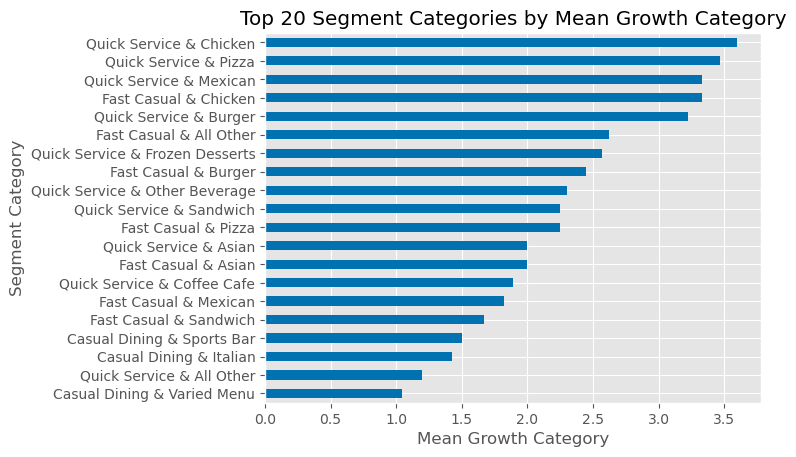

In [32]:
# Mean growth category by segment category
segment_mean_growth = (chains_growth
    .get(['Segment_Category', 'Growth_Category'])
    .groupby('Segment_Category')
    .mean()
)

top_20 = (segment_mean_growth
    .sort_values('Growth_Category', ascending=False)
    .reset_index()
    .take(np.arange(20))
)

# Plot horizontal bar chart (highest at the top)
(top_20
 .sort_values('Growth_Category', ascending=True)
 .plot(kind='barh',
       x='Segment_Category',
       y='Growth_Category',
       legend=False,
       xlabel='Mean Growth Category',
       ylabel='Segment Category',
       title='Top 20 Segment Categories by Mean Growth Category')
)

# Best three to invest in (computed from the data)
invest_segment_categories = np.array(
    top_20.sort_values('Growth_Category', ascending=False).get('Segment_Category').take(np.arange(3))
)

invest_segment_categories

In [33]:
grader.check("q1_12")

q1_12 results: All test cases passed!

<a id='part2'></a>
## Part 2 – Cities 🌆

Awesome! Now that we've gotten a feel for the `chains` dataset, let's move on to the `future` and `independents` datasets. Since both datasets include location information, we'll focus on identifying "hot food cities". 🔥 

Remember, the `future` DataFrame contains information about the fastest-growing chains with sales between \\$25 and \\$50 million – there's no overlap between the chains in `future` and the chains in `chains` since the "smallest" chain in `chains` made \\$96 million last year. In `future`,  we're given the locations where the chains are headquartered. In the `independents` DataFrame, the restaurants are not chains, so we're given their actual locations.

### Question 2.1
**1 point**

Let's start with the `independents` DataFrame. Unlike most of the restaurants in `chains`, many independent restaurants in our data set are 💲💲💲💲. Assign `most_expensive_restaurant` to a list containing the [`'Restaurant'`, `'City'`, `'Average Check'`] of the restaurant with the highest average check in the `independents` dataset. When creating this list, avoid typing the values by hand; get Python to extract the information for you.



In [34]:
row = independents.sort_values('Average Check', ascending=False).take([0])
row = row.get(['Restaurant', 'City', 'Average Check'])
most_expensive_restaurant = list(row.values[0])
most_expensive_restaurant

['Alinea', 'Chicago', 650]

In [35]:
grader.check("q2_1")

q2_1 results: All test cases passed!

### Question 2.2
**1 point**

Which restaurant in `independents` has the lowest sales per meal served? Assign the restaurant name to the variable `lowest_spm_restaurant` and also assign the sales per meal for this restaurant to `lowest_spm`.



In [36]:
sorted_df = independents.assign(
    Sales_Per_Meal = independents.get('Sales') / independents.get('Meals Served')
).sort_values('Sales_Per_Meal')

lowest_spm_restaurant = sorted_df.get('Restaurant').iloc[0]

lowest_spm = sorted_df.get('Sales_Per_Meal').iloc[0]
print(f"The restaurant with the lowest sales per meal is {lowest_spm_restaurant}; the sales per meal at this restaurant was {lowest_spm} dollars.")

The restaurant with the lowest sales per meal is Pancake Pantry; the sales per meal at this restaurant was 16.57718120805369 dollars.


In [37]:
grader.check("q2_2")

q2_2 results: All test cases passed!

### Question 2.3
**1 point**

Unless you spend a lot of time in Tennessee, chances are you've probably never heard of this restaurant. Here's how the restaurant describes itself on its [website](https://thepancakepantry.com/):

*Since 1961, we’ve been serving scratch-made pancakes and much more to visitors and locals alike. We start every day bright and early at 6 o’clock in the morning, offering our full menu with 23 scratch-made varieties of pancakes, fresh-cooked eggs and omelets, waffles, and even sandwiches and salads.*

Sorting `independents` by `Meals Served` shows that the `most_expensive_restaurant` served far fewer meals than the `lowest_spm_restaurant`, as you might expect. 

In [38]:
independents.sort_values('Meals Served')

,Rank,Restaurant,Sales,Average Check,City,State,Meals Served
99,100,Mélisse,11050000,425,Santa Monica,Calif.,26000
5,6,Alinea,27072500,650,Chicago,Ill.,41650
98,99,L'Atelier de Joël Robuchon Miami,11063000,195,Miami,Fla.,54215
81,82,China Live,12504518,54,San Francisco,Calif.,87882
96,97,Stubborn Seed,11158000,124,Miami Beach,Fla.,89986
...,...,...,...,...,...,...,...
84,85,Pancake Pantry,12350000,16,Gatlinburg,Tenn.,745000
63,64,Lambert's Cafe (Sikeston),14941000,18,Sikeston,Mo.,832000
45,46,Zehnder's of Frankenmuth,17027211,19,Frankenmuth,Mich.,908951
1,2,The Boathouse Orlando,39863628,44,Orlando,Fla.,921785


This may make you wonder if more expensive restaurants serve fewer meals in general. Create an appropriate data visualization based on the `independents` DataFrame that helps you answer this question.

<!-- BEGIN QUESTION -->



<Axes: xlabel='Average Check', ylabel='Meals Served'>

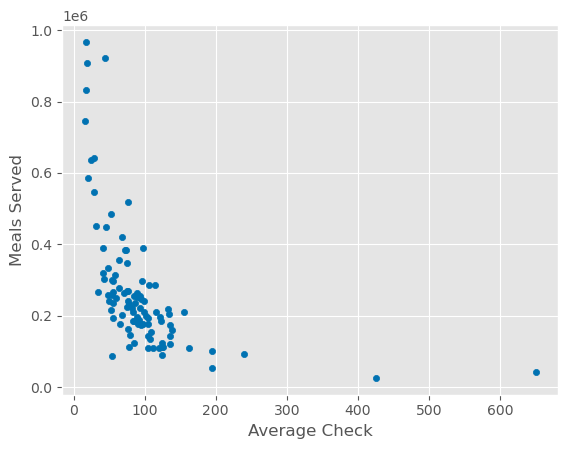

In [39]:
# Make your data visualization here.
independents.plot(kind = 'scatter', x = 'Average Check', y = 'Meals Served')

<!-- END QUESTION -->

### Question 2.4
**3 points**

Let's start working with the cities in the `independents` DataFrame. Run the following cell to get a feel for the type of cities that appear.

In [40]:
independents

,Rank,Restaurant,Sales,Average Check,City,State,Meals Served
0,1,Komodo,41000000,115,Miami,Fla.,285000
1,2,The Boathouse Orlando,39863628,44,Orlando,Fla.,921785
2,3,Swan,31000000,85,Miami,Fla.,185000
3,4,Maple & Ash (Chicago),30285684,106,Chicago,Ill.,285714
4,5,Mila,27350000,134,Miami Beach,Fla.,203990
...,...,...,...,...,...,...,...
95,96,George's at the Cove,11218000,93,La Jolla,Calif.,221671
96,97,Stubborn Seed,11158000,124,Miami Beach,Fla.,89986
97,98,Toulouse Cafe & Bar Houston,11074759,78,Houston,Texas,113609
98,99,L'Atelier de Joël Robuchon Miami,11063000,195,Miami,Fla.,54215


Some cities appear many times, like `'Miami'` and `'Miami Beach'` (which are actually two different cities). Others appear only once, like `'La Jolla'`.

Below, assign `city_checks` to a DataFrame with index `'City'` and column `'Average Check'`, containing the **median** `'Average Check'` in all cities with at least 3 restaurants in the dataset, sorted by median `'Average Check'` in decreasing order. The first few rows of `city_checks` should look like this:

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Average Check</th>
    </tr>
    <tr>
      <th>City</th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Las Vegas</th>
      <td>129.5</td>
    </tr>
    <tr>
      <th>Miami Beach</th>
      <td>129.0</td>
    </tr>
    <tr>
      <th>Chicago</th>
      <td>97.0</td>
    </tr>
  </tbody>
</table>

*Note*: This question is challenging and takes multiple steps, so feel free to break it down and use as many lines of code as you need.



In [41]:
# Median average check by city
city_medians = (independents
    .get(['City', 'Average Check'])
    .groupby('City')
    .median()
    .reset_index()
)

# Number of restaurants by city
city_counts = (independents
    .get(['City', 'Restaurant'])
    .groupby('City')
    .count()
    .reset_index()
)

city_counts = (city_counts
    .assign(Count = city_counts.get('Restaurant'))
    .drop(columns='Restaurant')
)

# Keep only cities with at least 3 restaurants, then sort by median check (descending)
city_checks = (city_medians
    .merge(city_counts, on='City')
)

city_checks = (city_checks[city_checks.get('Count') >= 3]
    .drop(columns='Count')
    .sort_values('Average Check', ascending=False)
    .set_index('City')
)

city_checks

,Average Check
City,
Las Vegas,129.5
Miami Beach,129.0
Chicago,97.0
New York,93.0
Miami,85.0
Fort Lauderdale,70.0
San Francisco,53.0
Orlando,52.0


In [42]:
grader.check("q2_4")

q2_4 results: All test cases passed!

### Question 2.5
**1 point**

Now we'll look at the cities in the `future` DataFrame.

In [43]:
future

,Rank,Restaurant,Location,Sales,YOY_Sales,Units,YOY_Units,Unit_Volume,Franchising
0,1,Duck Donuts,"Mechanicsburg, Pa.",50,28.50%,106,10.40%,495,Yes
1,2,Just Salad,"New York, N.Y.",50,28.10%,48,14.30%,1105,No
2,3,Eggs Up Grill,"Spartanburg, S.C.",49,71.20%,53,15.20%,992,Yes
3,4,Bubbakoo's Burritos,"Wall, N.J.",48,58.50%,63,46.50%,900,Yes
4,5,Pokeworks,"Irvine, Calif.",47,32.50%,65,14.00%,775,Yes
...,...,...,...,...,...,...,...,...,...
45,46,Starbird Chicken,"Sunnyvale, Calif.",21,78.30%,10,25.00%,3600,Yes
46,47,GFG Cafe Cuisine,"Rutherford, N.J.",20,111.60%,30,66.70%,840,Yes
47,48,Mango Mango Desserts,"New York, N.Y.",19,35.00%,26,23.80%,820,Yes
48,49,Common Bond Cafe,"Houston, Texas",19,35.30%,10,11.10%,1980,No


We're eventually going to want to merge `independents` and `future` by city, but right now we can't do that, since `future` does not have a column with just the name of the city in it. `future`'s `'Location'` column also includes the state's name.

Below, create a DataFrame called `future_with_city` with the `'Rank'`, `'Restaurant'`, `'Sales'`, and `'YOY_Sales'` columns from `future` but with an additional column, `'City'`, that contains the name of the city in which the restaurant is headquartered. The first few rows of `future_with_city` are shown below; the order of the columns in `future_with_city` must match the output below.

|    |   Rank | Restaurant   | City             |   Sales | YOY_Sales   |
|-----:|-------:|-------------:|-----------------:|--------:|------------:|
**0**     |      1 | Duck Donuts   | Mechanicsburg          |      50 | 28.50%      |
**1**       |      2 | Just Salad  | New York        |      50 | 28.10%      |
**2**       |      3 | Eggs Up Grill     | Spartanburg |      49 | 71.20%       |


*Hint*: If you pass in a `list` of columns to `.get`, the resulting DataFrame will have only the columns you listed, in the order that you listed them.



In [44]:
def get_city(x):
    return x.split(",")[0].strip()

future_with_city = (future
    .assign(City = future.get('Location').apply(get_city))
    .get(['Rank', 'Restaurant', 'City', 'Sales', 'YOY_Sales'])
)

future_with_city

,Rank,Restaurant,City,Sales,YOY_Sales
0,1,Duck Donuts,Mechanicsburg,50,28.50%
1,2,Just Salad,New York,50,28.10%
2,3,Eggs Up Grill,Spartanburg,49,71.20%
3,4,Bubbakoo's Burritos,Wall,48,58.50%
4,5,Pokeworks,Irvine,47,32.50%
...,...,...,...,...,...
45,46,Starbird Chicken,Sunnyvale,21,78.30%
46,47,GFG Cafe Cuisine,Rutherford,20,111.60%
47,48,Mango Mango Desserts,New York,19,35.00%
48,49,Common Bond Cafe,Houston,19,35.30%


In [45]:
grader.check("q2_5")

q2_5 results: All test cases passed!

### Question 2.6
**3 points**

We will say a "hot food city" is a city with at least one restaurant in the Independents 100 (`independents`) and at least one restaurant in the Future 50 (`future_with_city`).

Below, create a DataFrame `hot_cities` indexed by `'City'` and having two columns,  `'Independents_100'` and `'Future_50'`. Each row should correspond to a hot food city, and the values in the columns should represent the number of restaurants in that city that appear on the Independents 100 and Future 50, respectively. The first few rows of `hot_cities` should look like this:

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Independents_100</th>
      <th>Future_50</th>
    </tr>
    <tr>
      <th>City</th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Atlanta</th>
      <td>2</td>
      <td>2</td>
    </tr>
    <tr>
      <th>Austin</th>
      <td>2</td>
      <td>1</td>
    </tr>
    <tr>
      <th>Chicago</th>
      <td>16</td>
      <td>1</td>
    </tr>
  </tbody>
</table>



In [46]:
indep_counts = (independents
    .get(['City', 'Restaurant'])
    .groupby('City')
    .count()
    .reset_index()
)

indep_counts = (indep_counts
    .assign(Independents_100 = indep_counts.get('Restaurant'))
    .drop(columns='Restaurant')
)

future_counts = (future_with_city
    .get(['City', 'Restaurant'])
    .groupby('City')
    .count()
    .reset_index()
)

future_counts = (future_counts
    .assign(Future_50 = future_counts.get('Restaurant'))
    .drop(columns='Restaurant')
)

hot_cities = (indep_counts
    .merge(future_counts, on='City')
    .set_index('City')
)

hot_cities

,Independents_100,Future_50
City,,
Atlanta,2,2
Austin,2,1
Chicago,16,1
Houston,2,1
New York,10,2
Orlando,3,2
West Hollywood,1,1


In [47]:
grader.check("q2_6")

q2_6 results: All test cases passed!

### Question 2.7
**1 point**

For each city in `hot_cities`, let us define the "food hotness" of a city as the sum of the `Independents_100` and `Future_50` columns of `hot_cities`. In other words, the food hotness of a city is the total number of restaurants in `independents` located in that city plus the total number of mid-size chains in `future` headquartered there. 

To visualize the `hot_cities` DataFrame, create an overlaid horizontal bar chart showing, for each hot food city, how many of that city's restaurants appear on the Independents 100 rankings, and how many appear on the Future 50 rankings. 

Organize the cities so that the city with the highest food hotness appears at the top of the bar chart, and the city with the lowest food hotness appears at the bottom. While you will use food hotness to order the bars in your bar chart, each city should just have two bars, one for the Independents 100 and the other for the Future 50.





<!-- BEGIN QUESTION -->



<Axes: ylabel='City'>

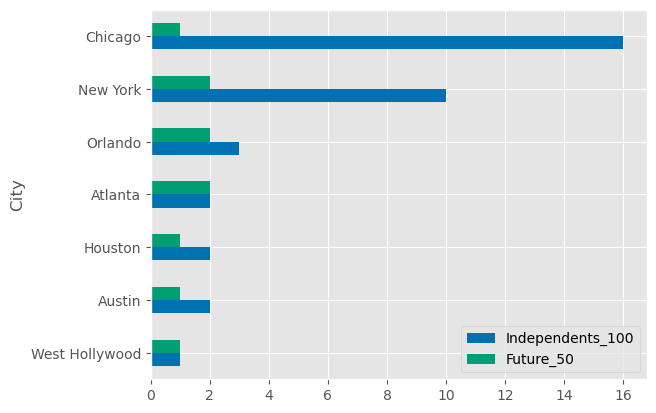

In [48]:
# Make your overlaid horizontal bar chart here.
hotness = hot_cities.assign(Food_Hotness = hot_cities.get('Independents_100') + hot_cities.get('Future_50'))

hotness_sorted = (hotness
    .sort_values('Food_Hotness', ascending=True)
    .drop(columns='Food_Hotness')
)

hotness_sorted.plot(kind='barh', stacked=False)

<!-- END QUESTION -->

### Question 2.8
**2 points**

Now, we want to compare the food hotness of a city with its population. Is it simply the case that larger cities are considered hotter because they have larger populations? How do we measure the "foodiness" of a city, taking into account its population?

Use the `populations` dataset loaded below to visually compare food hotness and 2021 population using a scatter plot. Then assign to `foodiest_city` the name of the city with the highest food hotness per capita. Food lovers, this is where you might want to plan your next vacation! ✈️


In [49]:
populations = bpd.read_csv("data/populations.csv")
populations

,name,usps,pop2021,pop2010,growth,density,aland_sqmi
0,New York,NY,8230290,8190210,0.0049,27400,300.381
1,Los Angeles,CA,3983540,3795510,0.0495,8494,468.956
2,Chicago,IL,2679080,2697480,-0.0068,11783,227.369
3,Houston,TX,2323660,2100280,0.1064,3630,640.194
4,Phoenix,AZ,1733630,1449040,0.1964,3349,517.673
...,...,...,...,...,...,...,...
195,Miramar,FL,142445,122300,0.1647,4937,28.853
196,Round Rock,TX,142418,100772,0.4133,3933,36.213
197,Metairie,LA,142135,138481,0.0264,6111,23.259
198,Olathe,KS,142119,126269,0.1255,2306,61.642


'West Hollywood'

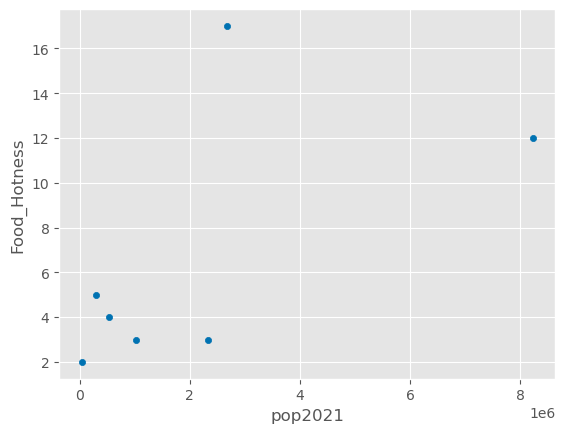

In [50]:
# Make merged DataFrame
# Reset the index for hot_cities, so merge is possible
food_city_df = hot_cities.reset_index().merge(populations, left_on = 'City', right_on = 'name')

# Add new column for Food Hotness
food_city_df = food_city_df.assign(Food_Hotness = food_city_df.get('Independents_100') + food_city_df.get('Future_50'))

# Add another column for Hotness Per City and sort
food_city_df = (food_city_df
                .assign(Hotness_Per_City = food_city_df.get('Food_Hotness') / food_city_df.get('pop2021'))
                .sort_values(by = 'Hotness_Per_City', ascending = False)
               )
# Make your scatter plot here.
food_city_df.plot(kind = 'scatter', x = 'pop2021', y = 'Food_Hotness')

# Find Foodiest City
foodiest_city = food_city_df.get('City').iloc[0]
foodiest_city

In [51]:
grader.check("q2_8")

q2_8 results: All test cases passed!

<a id='part3'></a>
## Part 3 – Stars ⭐️

So far, we have been looking at restaurant data from a company that provides business intelligence for restaurants. Therefore, our data has focused on important business concepts, like sales and growth. But are these profitable, fast-growing restaurants actually serving up delicious food that we want to eat? For that information, we ask the people of Yelp. 

In this section, we'll work with a dataset of Yelp ratings from January 2023 for the 100 restaurants in `independents`. In the cell below, we load in our Yelp data as a DataFrame called `ratings`.

In [52]:
ratings = bpd.read_csv('data/Yelp.csv')
ratings

,Restaurant,City,Rating
0,15th Street Fisheries,Fort Lauderdale,3.5
1,Abe & Louie's,Boston,4.0
2,Alinea,Chicago,4.5
3,Atlanta Fish Market,Atlanta,3.5
4,BOA Steakhouse,West Hollywood,4.0
...,...,...,...
95,The Spot,Galveston,3.5
96,Top of the World,Las Vegas,3.5
97,Toulouse Cafe & Bar Houston,Houston,3.5
98,Whiskey Joe's Tampa,Tampa,3.0


### Question 3.1
**1 point**

Notice that in the `independents` DataFrame, certain rows include the city name in parentheses as part of the restaurant name. An example is shown below.

In [53]:
independents.take([3])

,Rank,Restaurant,Sales,Average Check,City,State,Meals Served
3,4,Maple & Ash (Chicago),30285684,106,Chicago,Ill.,285714


This will be problematic if we try to merge the `independents` DataFrame and the `ratings` DataFrame, since `ratings` does not necessarily contain the city in parentheses in the `'Restaurant'` column.

To fix this, write a function called `remove_location`, which takes in a string value containing the restaurant name and removes any location information listed within parentheses. Example behavior of the function is shown below.

```py
>>> remove_location('Maple & Ash (Chicago)')
'Maple & Ash'

>>> remove_location('Beauty & Essex (New York City)')
'Beauty & Essex'

>>> remove_location('Casa Tua Miami')
'Casa Tua Miami'
```

Then, create two new DataFrames, `independents_to_merge` and `ratings_to_merge` with the same data as `independents` and `ratings`, except with no locations in parentheses in the `'Restaurant'` column.

*Hints:* 
- You may find the string method [index()](https://www.w3schools.com/python/ref_string_index.asp) useful for this question.  
- Make sure to remove any spaces that may be in front of the parentheses. 

In [54]:
def remove_location(name):
    location = name.split(' (')
    restaurant_name = location[0]
    # Remove white space
    return restaurant_name.strip()
    

In [55]:
grader.check("q3_1")

q3_1 results: All test cases passed!

In [56]:
independents_to_merge = independents.assign(
    Restaurant=independents.get('Restaurant').apply(remove_location)
)
independents_to_merge

,Rank,Restaurant,Sales,Average Check,City,State,Meals Served
0,1,Komodo,41000000,115,Miami,Fla.,285000
1,2,The Boathouse Orlando,39863628,44,Orlando,Fla.,921785
2,3,Swan,31000000,85,Miami,Fla.,185000
3,4,Maple & Ash,30285684,106,Chicago,Ill.,285714
4,5,Mila,27350000,134,Miami Beach,Fla.,203990
...,...,...,...,...,...,...,...
95,96,George's at the Cove,11218000,93,La Jolla,Calif.,221671
96,97,Stubborn Seed,11158000,124,Miami Beach,Fla.,89986
97,98,Toulouse Cafe & Bar Houston,11074759,78,Houston,Texas,113609
98,99,L'Atelier de Joël Robuchon Miami,11063000,195,Miami,Fla.,54215


### Question 3.2
**1 point**

It's worth thinking about why our Yelp review data includes `'City'` – isn't it enough to just have the name of the restaurant and its rating?

Well, no – not if there are multiple restaurants with the same name! Below, assign `duplicate_restaurants` to an array containing the names of restaurants in `independents_to_merge` that appear more than once. You don't need to sort them in any particular order.

In [57]:
counts = independents_to_merge.groupby('Restaurant').count()
duplicate_restaurants = np.array(counts[counts.get('City') > 1].index)
duplicate_restaurants

array(['Beauty & Essex', 'Gibsons Bar & Steakhouse',
       "Joe's Seafood, Prime Steak & Stone Crab", 'Maple & Ash'],
      dtype=object)

In [58]:
grader.check("q3_2")

q3_2 results: All test cases passed!

Next, we'll create a new DataFrame called `independents_with_ratings` by merging `independents_to_merge` and `ratings_to_merge` on both `'Restaurant'` and `'City'`.

We need to merge by both columns to correctly handle the duplicate restaurants we identified above. Think about what would happen if we merged by only `'Restaurant'`.

We haven't yet seen how to merge two DataFrames on multiple columns, but it turns out that if you just omit all the optional parameters in the call to `merge`, the DataFrames will be merged on all column labels that are common to both DataFrames.

Recall the column names of the `independents_to_merge` and `ratings_to_merge` DataFrames by running the next two cells.

In [59]:
independents_to_merge.columns

Index(['Rank', 'Restaurant', 'Sales', 'Average Check', 'City', 'State',
       'Meals Served'],
      dtype='object')

In [60]:
ratings_to_merge = ratings.assign(
    Restaurant=ratings.get('Restaurant').apply(remove_location)
)

ratings_to_merge.columns

Index(['Restaurant', 'City', 'Rating'], dtype='object')

The column names appearing in both DataFrames are exactly `'Restaurant'` and `'City'`, the two columns we want to merge on. This makes our call to `merge` simple. Run the cell below to merge the two DataFrames based on `'Restaurant'` and `'City'`.

In [61]:
independents_with_ratings = independents_to_merge.merge(ratings_to_merge) 
independents_with_ratings

,Rank,Restaurant,Sales,Average Check,City,State,Meals Served,Rating
0,1,Komodo,41000000,115,Miami,Fla.,285000,4.0
1,2,The Boathouse Orlando,39863628,44,Orlando,Fla.,921785,4.5
2,3,Swan,31000000,85,Miami,Fla.,185000,3.5
3,4,Maple & Ash,30285684,106,Chicago,Ill.,285714,4.0
4,5,Mila,27350000,134,Miami Beach,Fla.,203990,4.0
...,...,...,...,...,...,...,...,...
95,96,George's at the Cove,11218000,93,La Jolla,Calif.,221671,4.0
96,97,Stubborn Seed,11158000,124,Miami Beach,Fla.,89986,4.5
97,98,Toulouse Cafe & Bar Houston,11074759,78,Houston,Texas,113609,3.5
98,99,L'Atelier de Joël Robuchon Miami,11063000,195,Miami,Fla.,54215,4.5


### Question 3.3
**2 points**

For each state, find the proportion of independent restaurants in that state that have at least a 4 star rating. Save your result to a `Series` called `state_proportions` indexed by state name and sorted in ascending order.



In [62]:
independents_with_ratings = (independents_with_ratings
                             .assign(High_Rated = independents_with_ratings.get('Rating') >= 4)
                            )
state_statistics = independents_with_ratings.get(['State', 'High_Rated']).groupby('State').mean()
state_proportions = state_statistics.get('High_Rated').sort_values()
state_proportions

State
Mich.     0.000000
Texas     0.333333
Ga.       0.500000
N.J.      0.500000
Fla.      0.545455
            ...   
La.       1.000000
Ind.      1.000000
D.C.      1.000000
Texas.    1.000000
Va.       1.000000
Name: High_Rated, Length: 21, dtype: float64

In [63]:
grader.check("q3_3")

q3_3 results: All test cases passed!

### Question 3.4
**1 point**

Are higher-rated restaurants more expensive? Make a vertical bar chart of restaurant `'Rating'` versus **median**`'Average Check'` to see if there is an association between these variables. Note that we're thinking of `'Rating'` as a categorical variable here.



<!-- BEGIN QUESTION -->



<Axes: xlabel='Rating'>

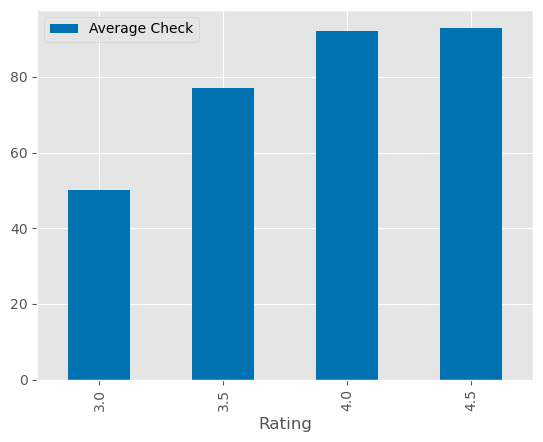

In [64]:
# Make your vertical bar chart here.
independents_with_ratings.get(['Rating', 'Average Check']).groupby('Rating').median().plot(kind = 'bar', y = 'Average Check')

<!-- END QUESTION -->

You should be able to see that higher-rated restaurants are more expensive, which should not be too surprising.

### Question 3.5
**3 points**

In the previous question, we thought of `'Rating'` as a categorical variable. Now let's treat `'Rating'` as a numerical variable and look at its distribution to understand what kind of ratings the restaurants in `independents_with_ratings` receive. 

#### Part a)
**1 point**

Set the variable `rating_bins` to an array of values such that:
- a  histogram of `'Rating'` with these bins has each distinct value of `'Rating'` in a separate bin, 
- there are no spaces between the bins, 
- the first bin includes the lowest value in the `'Rating'` column, and 
- the last bin includes the highest value in the `'Rating'` column.



In [65]:
# Find array of ratings for bin widths
independents_with_ratings.get('Rating').unique()

array([4. , 4.5, 3.5, 3. ])

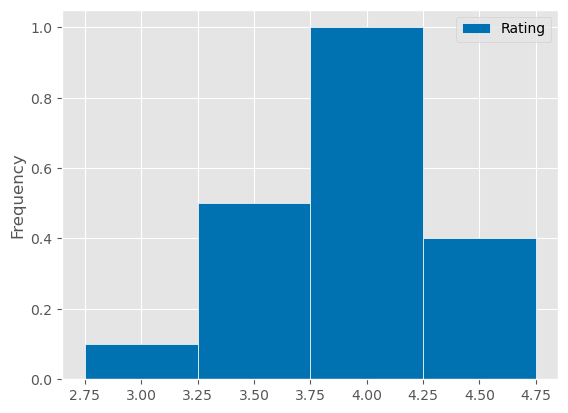

In [66]:
# Bin width is 0.5 stars. Use half-step offsets so each rating value is in its own bin.
min_rating = independents_with_ratings.get('Rating').min()
max_rating = independents_with_ratings.get('Rating').max()

rating_bins = np.arange(min_rating - 0.25, max_rating + 0.75, 0.5)

independents_with_ratings.plot(kind='hist', y='Rating', bins=rating_bins, density=True, ec = 'w');

In [67]:
grader.check("q3_5a")

q3_5a results: All test cases passed!

#### Part b)
**1 point**

Your histogram should show you that very few restaurants in `independents_with_ratings` got the lowest rating. In fact, there are only five! Set `worst_restaurants` to an array with the names of these restaurant, and get the average of `Average Check` of these five restaurants and assign this value to the variable `worst_avg_check`.


In [68]:
# Sort by rating and take the top 5 rows
worst_five_df = independents_with_ratings.sort_values('Rating').take(np.arange(5))

worst_restaurants =  np.array(worst_five_df.get('Restaurant'))
worst_avg_check = worst_five_df.get('Average Check').mean()

print(f"The worst restaurants are {worst_restaurants}; the average check at these restaurant is {worst_avg_check} dollars.")


The worst restaurants are ['Paradise Cove Beach Cafe' "Whiskey Joe's Tampa"
 'Grand Central Oyster Bar' 'Gladstones' 'Frankenmuth Bavarian Inn']; the average check at these restaurant is 46.8 dollars.


In [69]:
grader.check("q3_5b")

q3_5b results: All test cases passed!



#### Part c)
**1 point**

In a density histogram, it can be hard to tell the exact height of a bar from looking at the histogram, but if you know the data from which the histogram was generated, you should be able to figure it out. Use `independents_with_ratings` to determine the exact height of the bar in the histogram that corresponds to restaurants with a rating of 3.5 stars. Save your result as `hist_height`.

*Hint*: You can check if your answer is approximately correct by inspecting the histogram in Part (a).



In [70]:
# 1. Count how many have 3.5 stars
count_3_5 = independents_with_ratings[independents_with_ratings.get('Rating') == 3.5].shape[0]

# 2. Get total number of restaurants
total_restaurants = independents_with_ratings.shape[0]

# 3. Calculate proportion (Area of the bar)
proportion_3_5 = count_3_5 / total_restaurants

# 4. Calculate Height (Proportion / Width)
# The width of the bin [3.5, 4.0) is 0.5
hist_height = proportion_3_5 / 0.5
hist_height = proportion_3_5 / 0.5
hist_height

0.5

In [71]:
grader.check("q3_5c")

q3_5c results: All test cases passed!

### Question 3.6
**3 points**

Lastly, we want to examine the relationship between average check and star rating, separately in each city. To do this, we can use `.groupby` with subgroups. Create a DataFrame called `check_by_city_and_rating` that shows the **median** `'Average Check'` value of restaurants for each city-rating combination. Since there are many such pairs, limit their number in two ways:
- Only include cities that have at least three restaurants in `independents_with_ratings`.
- Only include full stars earned in the rating. For example, a rating of 3.5 should be counted the same as a rating of 3.0 for this problem.

The first few rows of `check_by_city_and_rating` should look like this:

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th></th>
      <th>Average Check</th>
    </tr>
    <tr>
      <th style="text-align: right;">City</th>
      <th>Rounded_Rating</th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th rowspan="2" valign="top" style="text-align: right;">Chicago</th>
      <th>3.0</th>
      <td>82.0</td>
    </tr>
    <tr>
      <th>4.0</th>
      <td>99.0</td>
    </tr>
    <tr>
      <th rowspan="2" valign="top" style="text-align: right;">Fort Lauderdale</th>
      <th>3.0</th>
      <td>72.0</td>
    </tr>
    <tr>
      <th>4.0</th>
      <td>68.0</td>
    </tr>
    <tr>
      <th style="text-align: right;">Las Vegas</th>
      <th>3.0</th>
      <td>122.0</td>
    </tr>
  </tbody>
</table>

*Hint*: The function `np.floor` should be useful here. Feel free to look up what it does.

*Note*: This question is similar to Question 2.4, where we looked at the median `'Average Check'` by city. Referring back to how you solved that problem might be helpful. As with Question 2.4, this is a challenging problem that takes multiple steps, so feel free to break it down and use as many lines of code as you need.




In [72]:
# Round ratings down to full stars (3.5 counts as 3.0)
rating_rounded_df = independents_with_ratings.assign(
    Rounded_Rating = np.floor(independents_with_ratings.get('Rating'))
)

# Only keep cities with at least 3 restaurants
city_counts = rating_rounded_df.groupby('City').count().reset_index()
popular_cities = city_counts[city_counts.get('Restaurant') >= 3].get(['City'])

df_filtered = rating_rounded_df.merge(popular_cities, on='City')

check_by_city_and_rating = (df_filtered
    .get(['City', 'Rounded_Rating', 'Average Check'])
    .groupby(['City', 'Rounded_Rating'])
    .median()
)

check_by_city_and_rating

Average Check
City            Rounded_Rating               
Chicago         3.0                      82.0
                4.0                      99.0
Fort Lauderdale 3.0                      72.0
                4.0                      68.0
Las Vegas       3.0                     122.0
...                                       ...
Miami Beach     4.0                     124.0
New York        3.0                      79.0
                4.0                      96.0
Orlando         4.0                      52.0
San Francisco   4.0                      53.0

[14 rows x 1 columns]

In [73]:
grader.check("q3_6")

q3_6 results: All test cases passed!

## Congratulations! You've completed the Midterm Project!

Just a few things left:

**_Citations:_** Did you use any generative artificial intelligence tools to assist you on this assignment? If so, please state, for each tool you used, the name of the tool (ex. ChatGPT) and the problem(s) in this assignment where you used the tool for help.

<hr style="color:Maroon;background-color:Maroon;border:0 none; height: 3px;">

Please cite tools here.

<hr style="color:Maroon;background-color:Maroon;border:0 none; height: 3px;">

## Submission Instructions 📧

As usual, follow these steps to submit your assignment:

Select `Kernel -> Restart & Run All` to ensure that you have executed all cells, including the test cells.
1. Read through the notebook to make sure everything is fine and all tests passed.
1. Run the cell below to run all tests, and make sure that they all pass.
1. Download your notebook using `File -> Download as -> Notebook (.ipynb)`, then upload your notebook to Gradescope. 
1. If working with a partner, don't forget to add your partner as a group member on Gradescope!
1. Stick around while the Gradescope autograder grades your work. Make sure you see that all tests have passed on Gradescope.
1. Check that you have a confirmation email from Gradescope and save it as proof of your submission.

If running all the tests at once causes a test to fail that didn't fail when you ran the notebook in order, check to see if you changed a variable's value later in your code. Make sure to use new variable names instead of reusing ones that are used in the tests. 

Remember, the tests here and on Gradescope just check the format of your answers. We will run correctness tests after the due date has passed.

In [74]:
grader.check_all()

q1_1 results: All test cases passed!

q1_10 results: All test cases passed!

q1_11 results: All test cases passed!

q1_12 results: All test cases passed!

q1_2 results: All test cases passed!

q1_3 results: All test cases passed!

q1_4 results: All test cases passed!

q1_5 results: All test cases passed!

q1_6 results: All test cases passed!

q1_7a results: All test cases passed!

q1_7b results: All test cases passed!

q1_8 results: All test cases passed!

q1_9 results: All test cases passed!

q2_1 results: All test cases passed!

q2_2 results: All test cases passed!

q2_4 results: All test cases passed!

q2_5 results: All test cases passed!

q2_6 results: All test cases passed!

q2_8 results: All test cases passed!

q3_1 results: All test cases passed!

q3_2 results: All test cases passed!

q3_3 results: All test cases passed!

q3_5a results: All test cases passed!

q3_5b results: All test cases passed!

q3_5c results: All test cases passed!

q3_6 results: All test cases passed!